# The escalated case: Meera's question on what stayed sold

**Week 1, Monday, afternoon. Alone, 35 minutes.** The six chapters answered Meera on booked
orders. Anand Iyer has read the draft and pushes back: "Booked includes orders we cancelled and
orders that came back. Do it again on what was delivered and stayed delivered, and tell me
whether your answer survives." Same 30 orders, 1 July to 26 September 2026.

> **Kavya's review.** Rebuild it on delivered orders and say what moved and what held. If the
> branch changes on Anand's definition, Meera needs to know before Thursday.

Every placeholder is filled with the right option, and the notebook was executed from a fresh
kernel. Under each part sits why the other options fail.

**The answer string:** `cbdcaabbc`.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

ORDERS = kit.load_records()

from datetime import date
for order in ORDERS:
    order["amount"] = int(order["amount"])     # chapter 1's fix
end = date.fromisoformat(max(o["order_date"] for o in ORDERS))
print(len(ORDERS), "orders loaded; the extract ends on", end)

30 orders loaded; the extract ends on 2026-09-26


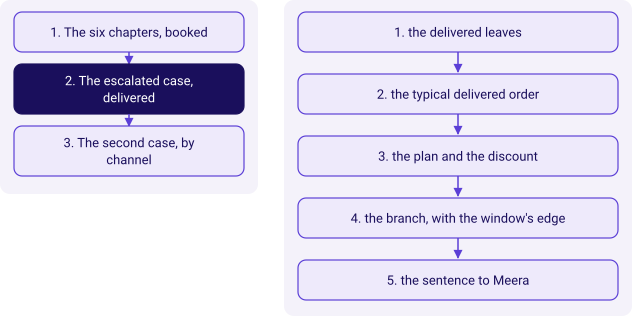

In [2]:
kit.side_by_side(
    kit.ladder(["The six chapters, booked", "The escalated case, delivered", "The second case, by channel"],
               lit=1, show=False),
    kit.vflow(["1. the delivered leaves", "2. the typical delivered order", "3. the plan and the discount",
               "4. the branch, with the window's edge", "5. the sentence to Meera"], show=False),
)

## Part 1. The leaves on what stayed delivered

**Post:** delivered orders, delivered customers and delivered orders per customer.

leaf,booked (the chapters),delivered
orders,30,21
customers,23,19
orders per customer,1.30,1.11
revenue,"Rs 5,44,810","Rs 5,20,790"


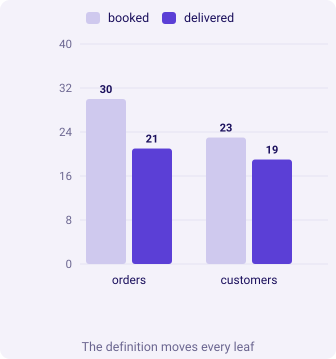

In [3]:
# TODO 1. Which condition keeps the orders that reached a customer and stayed there?
#   a) order["status"] != "cancelled"
#   b) order["status"] in ("delivered", "returned")
#   c) order["status"] == "delivered"
#   d) order["amount"] > 0
delivered, delivered_ids, delivered_revenue = [], [], 0
for order in ORDERS:
    if order["status"] == "delivered":
        delivered.append(order)
        delivered_ids.append(order["customer_id"])
        delivered_revenue += order["amount"]

# TODO 2. Which expression counts the distinct customers behind the delivered orders?
#   a) len(delivered_ids)
#   b) len(set(delivered_ids))
#   c) len(set(o["customer_id"] for o in ORDERS))
#   d) len(delivered)
delivered_customers = len(set(delivered_ids))

# TODO 3. Which expression is orders per customer on the delivered definition?
#   a) delivered_customers / len(delivered)
#   b) len(ORDERS) / delivered_customers
#   c) len(delivered) / 23
#   d) len(delivered) / delivered_customers
delivered_per_customer = len(delivered) / delivered_customers
kit.table(["leaf", "booked (the chapters)", "delivered"],
          [("orders", 30, len(delivered)), ("customers", 23, delivered_customers),
           ("orders per customer", "1.30", f"{delivered_per_customer:.2f}"),
           ("revenue", "Rs 5,44,810", kit.rupees(delivered_revenue))],
          caption="The same file on two definitions")
kit.columns(["orders", "customers"], [("booked", [30, 23]), ("delivered", [len(delivered), delivered_customers])],
            title="The definition moves every leaf")

In [4]:
kit.check("21 orders were delivered", len(delivered) == 21, len(delivered))
kit.check("delivered customers are fewer than delivered orders", delivered_customers < len(delivered))
kit.check("delivered orders per customer sits above one", delivered_per_customer > 1)

**Why not the others.** TODO 1: a keeps returns, which did not stay sold; b keeps them on
purpose, a different definition; d keeps everything. TODO 2: a counts rows; c counts booked
customers, mixing two definitions in one leaf; d counts orders. TODO 3: a is upside down; b
puts booked orders over delivered customers; c divides by the booked customer count.
**The numbers.** 21 orders, 19 customers, 1.11 each, Rs 5,20,790.

## Part 2. The typical delivered order

21 is an odd count, so the median is one value, not the average of two.

**Post:** the delivered mean, the delivered median, and the orders above the mean.

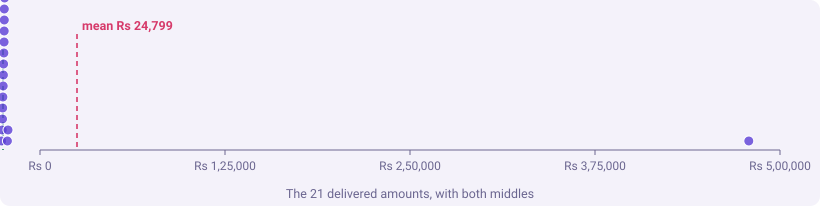

In [5]:
amounts = sorted(o["amount"] for o in delivered)
n = len(amounts)
mean_order = sum(amounts) / n
# TODO 4. n is 21, an odd count. Which expression is the median?
#   a) (amounts[n // 2 - 1] + amounts[n // 2]) / 2
#   b) amounts[n // 2 + 1]
#   c) amounts[n // 2]
#   d) sum(amounts) / n
median_order = amounts[n // 2]
# TODO 5. Which test counts an order as sitting above the mean?
#   a) amount > mean_order
#   b) amount > median_order
#   c) amount >= 0
#   d) amount < mean_order
above = 0
for amount in amounts:
    if amount > mean_order:
        above += 1
kit.stats([(kit.rupees(round(mean_order)), "delivered mean", "every delivered amount / 21"),
           (kit.rupees(median_order), "delivered median", "the 11th of 21 in size order"),
           (f"{above} of {n}", "above the mean", "the rest sit below")])
kit.strip(amounts, markers=[("mean", mean_order, "bad"), ("median", median_order, "good")],
          title="The 21 delivered amounts, with both middles")

In [6]:
kit.check("the median is one of the delivered amounts", median_order in amounts)
kit.check("the delivered mean sits more than ten times above the median", mean_order > 10 * median_order)
kit.check("almost every delivered order sits below the mean", n - above >= 20)

**Why not the others.** TODO 4: a is the even-count rule, which here averages the 10th and 11th;
b is one place past the middle; d is the mean. TODO 5: b counts orders above the median, about
half by construction; c counts everything; d counts the other side.
**The numbers.** Mean Rs 24,800, median Rs 2,060, 1 of 21 above the mean. The mean rose by
Rs 6,640 from the booked Rs 18,160 and the median fell Rs 145, so the typical order held.

## Part 3. The plan, and the discount marketing will propose

As in chapter 5, the plan is sized on the everyday orders, since no retention offer moves the
order at the top of chapter 4's sort.

**Post:** the everyday delivered orders the plan needs from frequency alone, and what a 15
percent discount that lifts orders 10 percent does to delivered revenue.

question,answer
the plan on everyday delivered revenue,"Rs 40,790 to Rs 46,908"
everyday delivered orders the plan needs from frequency alone,"23.00, 3.00 more"
all delivered revenue after the discount,"Rs 4,86,939, -6.5%"


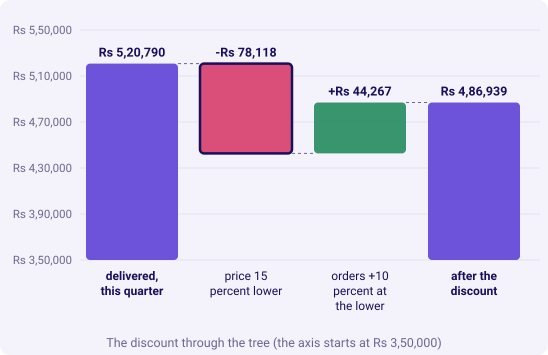

In [7]:
top = max(delivered, key=lambda o: o["amount"])       # the order chapter 4's sort found
kept = [o for o in delivered if o is not top]          # the everyday delivered orders
kept_revenue = sum(o["amount"] for o in kept)
plan = kept_revenue * 1.15
# TODO 6. If only frequency moves, how many everyday delivered orders must the same customers place?
#   a) len(kept) * 1.15
#   b) len(kept) + 15
#   c) len(kept) + 0.15
#   d) len(set(o["customer_id"] for o in kept)) * 1.15
needed_orders = len(kept) * 1.15
# TODO 7. A 15 percent discount lifts orders 10 percent. What multiplies delivered revenue?
#   a) 1 - 0.15 + 0.10
#   b) 0.85 * 1.10
#   c) 1.15 * 1.10
#   d) (1 - 0.15) * (1 - 0.10)
discount_factor = 0.85 * 1.10
after_discount = delivered_revenue * discount_factor
kit.table(["question", "answer"],
          [("the plan on everyday delivered revenue", f"{kit.rupees(round(kept_revenue))} to {kit.rupees(round(plan))}"),
           ("everyday delivered orders the plan needs from frequency alone", f"{needed_orders:.2f}, {needed_orders - len(kept):.2f} more"),
           ("all delivered revenue after the discount", f"{kit.rupees(round(after_discount))}, {discount_factor - 1:+.1%}")],
          caption="The plan and the discount on what stayed delivered")
kit.bridge(("delivered, this quarter", delivered_revenue),
           [("price 15 percent lower", -round(delivered_revenue * 0.15)),
            ("orders +10 percent at the lower price", round(delivered_revenue * 0.85 * 0.10))],
           end_label="after the discount", lit=(0,), lo=350000,
           title="The discount through the tree (the axis starts at Rs 3,50,000)")

In [8]:
kit.check("frequency alone reaches the plan", abs(needed_orders * (kept_revenue / len(kept)) - plan) < 1)
kit.check("the discount lowers delivered revenue", after_discount < delivered_revenue)

**Why not the others.** TODO 6: d is the customers answer; b adds 15 orders, a 75 percent lift;
c adds 0.15 of an order. TODO 7: a adds the moves and calls a fall a rise; c raises the price; d
cuts orders instead of lifting them.
**The numbers.** On the 20 everyday delivered orders, Rs 40,790, the plan is Rs 46,908; frequency
alone needs 23 of them, 3 more; the discount takes all delivered revenue to Rs 4,86,939, a 6.5
percent fall.

## Part 4. The branch, with the window's edge

Count the one-time buyers on delivered orders, then hold back the ones too recent to judge,
using chapter 6's typical gap of 45 days.

**Post:** delivered customers who bought once, how many of them are too recent, and the branch.

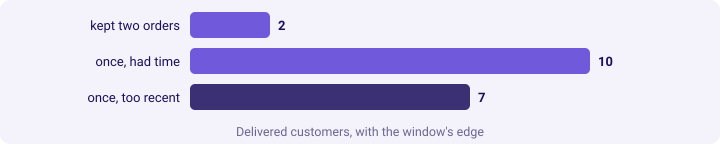

open first: frequency


In [9]:
firsts = {}
for order in delivered:
    firsts.setdefault(order["customer_id"], []).append(date.fromisoformat(order["order_date"]))
once = [cid for cid, days in firsts.items() if len(days) == 1]
typical_gap = 45                                   # chapter 6, from the booked repeat buyers
# TODO 8. Which test flags a one-time buyer as too recent to judge?
#   a) days_since > typical_gap
#   b) days_since < typical_gap
#   c) days_since == 0
#   d) typical_gap < 45
too_recent = 0
for cid in once:
    days_since = (end - firsts[cid][0]).days
    if days_since < typical_gap:
        too_recent += 1
# TODO 9. On delivered orders, which branch does Meera open first?
#   a) "customers"
#   b) "price"
#   c) "frequency"
#   d) "order value"
first_branch = "frequency"
kit.bars([("kept two orders", delivered_customers - len(once)), ("once, had time", len(once) - too_recent),
          ("once, too recent", too_recent)], lit=(2,), title="Delivered customers, with the window's edge")
print("open first:", first_branch)

In [10]:
kit.check("every delivered customer is counted once", len(firsts) == delivered_customers)
kit.check("some one-time buyers are too recent to judge", 0 < too_recent < len(once))
kit.check("the branch is the one the one-time buyers point to", first_branch == "frequency")

**Why not the others.** TODO 8: a flags the ones who had time; c catches only a same-day order;
d compares the gap with itself. TODO 9: a is marketing's branch, which one window cannot show
falling; b and d rest on fields this file lacks and on a mean one order drags.
**The numbers.** 17 of 19 delivered customers kept one order, 7 of them too recent to judge;
only 2 kept two orders. Frequency stays first, and the delivered view adds a leak: customers
come back, and their second orders are the ones cancelled or returned.

## Part 5. The sentence to Meera

Write one sentence in chapter 6's four parts, on delivered orders, and say what held from the
booked answer. Post it as text.

One sentence that holds: "On the 21 delivered orders from 1 July to 26 September, 19 customers
kept 1.11 orders each at a typical Rs 2,060, and 17 kept only one, 7 of them too recent to
judge, so frequency is still the branch to open first, with the second order's returns and
cancellations as the leak to fix; one quarter cannot show which branch moved, so hold the
Rs 12 crore until Tuesday's two quarters."

In [11]:
kit.table(["part", "booked (the chapters)", "delivered (this case)", "held?"],
          [("orders per customer", "1.30", f"{delivered_per_customer:.2f}", "fell"),
           ("typical order", "Rs 2,205", kit.rupees(median_order), "held"),
           ("one-time buyers", "16 of 23, 9 too recent", f"{len(once)} of {delivered_customers}, {too_recent} too recent", "held"),
           ("branch", "frequency", first_branch, "held")],
          caption="What moved and what held")
kit.check_summary()

part,booked (the chapters),delivered (this case),held?
orders per customer,1.30,1.11,fell
typical order,"Rs 2,205","Rs 2,060",held
one-time buyers,"16 of 23, 9 too recent","17 of 19, 7 too recent",held
branch,frequency,frequency,held
